# Análisis descriptivo y calidad de datos — Retail

**Universidad EAFIT • Fundamentos en Ciencia de Datos**

Este notebook adapta la estructura sencilla del cuaderno base de equinos al conjunto de datos de
ventas retail. Se usan:

- `retail_ventas_LIMPIO.csv` para la **Parte 1** y la interpretación final.
- `retail_ventas_CONTAMINADO.csv` para la **Parte 2**, sin utilizar el archivo limpio para reemplazar
  valores durante la limpieza.
- `reseñas_clientes.json` para la Tarea 1 (recolección multi-fuente): se integra como fuente
  semi-estructurada y se cruza por `store_id` con las ventas.

> **Declaración de uso de IA:** se utilizó IA generativa para apoyar la organización del notebook,
> la escritura inicial del código y la redacción. Los resultados fueron ejecutados y contrastados
> con las reglas del diccionario de variables. La interpretación y la decisión final deben ser
> revisadas y defendidas por el equipo.

## 0. Configuración inicial y carga de datos

In [1]:
from pathlib import Path
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Busca los archivos tanto en la carpeta actual como en la carpeta superior.
def buscar_archivo(nombre):
    candidatos = [
        Path.cwd() / "data" / "raw" / nombre,
        Path.cwd().parent / "data" / "raw" / nombre,
        Path.cwd() / ".." / "data" / "raw" / nombre,
    ]
    for ruta in candidatos:
        ruta = ruta.resolve()
        if ruta.exists():
            return ruta
    raise FileNotFoundError(f"No se encontró {nombre}")


ruta_limpio = buscar_archivo("retail_ventas_LIMPIO.csv")
ruta_contaminado = buscar_archivo("retail_ventas_CONTAMINADO.csv")

# Carpeta raíz del proyecto: .../data/raw/archivo.csv -> sube tres niveles.
raiz_proyecto = ruta_contaminado.parents[2]
carpeta_resultados = raiz_proyecto / "results"
carpeta_figuras = carpeta_resultados / "figuras"
carpeta_resultados.mkdir(parents=True, exist_ok=True)
carpeta_figuras.mkdir(parents=True, exist_ok=True)

df_limpio = pd.read_csv(ruta_limpio)
df_contaminado = pd.read_csv(ruta_contaminado)

print("LIMPIO:", df_limpio.shape)
print("CONTAMINADO:", df_contaminado.shape)

df_limpio.info()
df_limpio.head()

LIMPIO: (420, 11)
CONTAMINADO: (430, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   420 non-null    object 
 1   store_id         420 non-null    object 
 2   comuna           420 non-null    object 
 3   date             420 non-null    object 
 4   category         420 non-null    object 
 5   units_sold       420 non-null    int64  
 6   unit_price       420 non-null    float64
 7   payment_method   420 non-null    object 
 8   customer_rating  420 non-null    int64  
 9   store_lat        420 non-null    float64
 10  store_lon        420 non-null    float64
dtypes: float64(3), int64(2), object(6)
memory usage: 36.2+ KB


,transaction_id,store_id,comuna,date,category,units_sold,unit_price,payment_method,customer_rating,store_lat,store_lon
0,T00001,S02,Laureles,2025-05-09,Bebidas,2,5100.0,App,5,6.24625,-75.58917
1,T00002,S02,Laureles,2025-06-03,Pasteles,4,8900.0,App,3,6.24605,-75.58977
2,T00003,S07,Aranjuez,2025-05-31,Snacks,1,3300.0,Tarjeta,4,6.27391,-75.55584
3,T00004,S04,Robledo,2025-06-07,Pan,3,3200.0,Efectivo,5,6.27054,-75.59354
4,T00005,S02,Laureles,2025-01-26,Bebidas,5,2100.0,Tarjeta,3,6.24270,-75.58825


In [2]:
# Estructura y tipos detectados por pandas
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   420 non-null    object 
 1   store_id         420 non-null    object 
 2   comuna           420 non-null    object 
 3   date             420 non-null    object 
 4   category         420 non-null    object 
 5   units_sold       420 non-null    int64  
 6   unit_price       420 non-null    float64
 7   payment_method   420 non-null    object 
 8   customer_rating  420 non-null    int64  
 9   store_lat        420 non-null    float64
 10  store_lon        420 non-null    float64
dtypes: float64(3), int64(2), object(6)
memory usage: 36.2+ KB


## Tarea 1 — Recolección de datos multi-fuente

La guía exige cargar las tres fuentes suministradas, no solo los dos archivos tabulares. Antes de
limpiar nada hay que registrar qué formato trae cada variable y si viene de una fuente
estructurada (CSV) o semi-estructurada (JSON).

In [3]:
ruta_resenas = buscar_archivo("reseñas_clientes.json")
with open(ruta_resenas, encoding="utf-8") as archivo:
    resenas_json = json.load(archivo)

df_resenas = pd.json_normalize(resenas_json)

print("RESEÑAS:", df_resenas.shape)
df_resenas.info()
df_resenas.head()

RESEÑAS: (160, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   review_id  160 non-null    object 
 1   store_id   160 non-null    object 
 2   date       160 non-null    object 
 3   rating     146 non-null    float64
 4   text       160 non-null    object 
 5   sentiment  0 non-null      object 
dtypes: float64(1), object(5)
memory usage: 7.6+ KB


,review_id,store_id,date,rating,text,sentiment
0,R0001,S03,2025-03-07,4.0,Demasiado costoso para la calidad,None
1,R0002,S03,2025-06-07,4.0,Buena variedad de productos,None
2,R0003,S05,2025-06-11,5.0,El local estaba desordenado,None
3,R0004,S02,2025-02-27,NaN,"Regular, esperaba más",None
4,R0005,S06,2025-01-06,4.0,Muy buen servicio y pan fresco,None


**Decisión — aplanado del JSON.** `pd.json_normalize` no generó columnas con puntos ni listas
anidadas: cada reseña ya es un registro plano con seis campos (`review_id`, `store_id`, `date`,
`rating`, `text`, `sentiment`). Es un hallazgo en sí mismo, no un paso trivial: la guía advierte
sobre aplanar estructuras anidadas, pero en este archivo no existía esa anidación, así que no hay
que inventar una decisión de aplanado que el dato no exige.

In [4]:
inventario_variables = pd.DataFrame({
    "Variable": [
        "transaction_id", "store_id", "comuna", "date", "category", "units_sold",
        "unit_price", "payment_method", "customer_rating", "store_lat", "store_lon",
        "review_id", "rating", "text", "sentiment"
    ],
    "Tipo de dato": [
        "Nominal (identificador)", "Nominal", "Nominal", "Fecha", "Nominal", "Discreta",
        "Continua", "Nominal", "Ordinal", "Geoespacial", "Geoespacial",
        "Nominal (identificador)", "Ordinal", "Nominal (texto libre)", "Nominal (vacía)"
    ],
    "Formato de origen": ["CSV"] * 11 + ["JSON"] * 4,
    "Tipo de fuente": ["Estructurada"] * 11 + ["Semi-estructurada"] * 4
})
inventario_variables

,Variable,Tipo de dato,Formato de origen,Tipo de fuente
0,transaction_id,Nominal (identificador),CSV,Estructurada
1,store_id,Nominal,CSV,Estructurada
2,comuna,Nominal,CSV,Estructurada
3,date,Fecha,CSV,Estructurada
4,category,Nominal,CSV,Estructurada
5,units_sold,Discreta,CSV,Estructurada
6,unit_price,Continua,CSV,Estructurada
7,payment_method,Nominal,CSV,Estructurada
8,customer_rating,Ordinal,CSV,Estructurada
9,store_lat,Geoespacial,CSV,Estructurada


**Nota — Tarea 1.2.** Este inventario cubre las 15 variables de las tres fuentes; es distinto
de la taxonomía de 5 variables de la sección 1.1, que responde una pregunta puntual del
documento (qué medida de centro usar), no un inventario completo. `review_id`, `rating`,
`text` y `sentiment` no tienen equivalente en los CSV: son las únicas variables
semi-estructuradas del proyecto, y `text` es la única de formato libre (no categórico ni
numérico).

**Pregunta de reflexión — Tarea 1.** ¿Qué información se pierde o se distorsiona al forzar una
fuente semi-estructurada dentro de una tabla rectangular?

Se pierde la razón del rating. La columna `text` es la única variable de esta fuente donde vive
el motivo del puntaje: en S07 (Aranjuez), la queja más repetida es *"El local estaba
desordenado"* (5 de 27 reseñas). Ese texto explica por qué el rating es bajo, pero para poder
cruzar las reseñas con las ventas por tienda (siguiente sección) hay que agregar por `store_id`
y quedarse solo con el promedio numérico de `rating`. En ese paso de agregación la causa
desaparece: el número dice *cuánto* cayó la satisfacción, no *por qué* cayó. Aplanar y agregar
una fuente semi-estructurada rectangular siempre cambia la pregunta que se puede responder con
ella.

In [5]:
rating_por_tienda_json = df_resenas.groupby("store_id")["rating"].mean().round(2)
rating_por_tienda_csv = df_contaminado.groupby("store_id")["customer_rating"].mean().round(2)

comparacion_rating = pd.DataFrame({
    "rating_promedio_resenas": rating_por_tienda_json,
    "rating_promedio_ventas": rating_por_tienda_csv
})
comparacion_rating["diferencia"] = (
    comparacion_rating["rating_promedio_resenas"] - comparacion_rating["rating_promedio_ventas"]
).round(2)

comparacion_rating.sort_values("diferencia")

,rating_promedio_resenas,rating_promedio_ventas,diferencia
store_id,,,
S04,3.62,4.05,-0.43
S03,3.62,3.90,-0.28
S07,3.61,3.83,-0.22
S02,3.77,3.95,-0.18
S01,4.08,4.03,0.05
S06,4.06,3.98,0.08
S08,4.15,4.02,0.13
S05,4.11,3.92,0.19


**Hallazgo.** Las dos fuentes no siempre coinciden. En S04, S03 y S07 el rating de las reseñas
es más bajo que el de las ventas (hasta 0,43 puntos de diferencia); en S05, S06 y S08 ocurre lo
contrario. Esto no es un error de carga: son dos instrumentos distintos midiendo satisfacción
(una calificación puntual en el momento de pago vs. una reseña posterior, más deliberada) y no
tienen por qué coincidir. Cualquier conclusión de la Parte 3 sobre la tienda peor calificada debe
decir de cuál de las dos fuentes viene el número, porque la respuesta cambia según cuál se use.
La comparación usa el archivo contaminado porque en este punto la limpieza aún no ha ocurrido;
recalculada sobre los datos ya procesados, ninguna diferencia cambia de signo y el desplazamiento
máximo es de 0,10 puntos.

---
## Parte 1 — Análisis estadístico general

### 1.1 — Taxonomía

Se clasifican cinco variables según el significado del dato, no solamente según el tipo que muestra
Python.

In [6]:
taxonomia = pd.DataFrame({
    "Variable": ["store_id", "category", "customer_rating", "units_sold", "unit_price"],
    "Clasificación": ["Nominal", "Nominal", "Ordinal", "Discreta", "Continua"],
    "Medida central válida": ["Moda", "Moda", "Mediana o moda", "Media, mediana o moda", "Media o mediana"],
    "Justificación": [
        "Es una etiqueta de tienda sin orden; promediar sus códigos no tiene significado.",
        "Son nombres de productos sin jerarquía; la categoría más frecuente se resume con la moda.",
        "Los valores 1 a 5 tienen orden, pero no garantizan distancias iguales; se usa mediana o moda.",
        "Cuenta unidades enteras; admite media, mediana y moda según la forma de la distribución.",
        "Es una magnitud monetaria con diferencias interpretables; admite media o mediana según el sesgo."
    ]
})
taxonomia

,Variable,Clasificación,Medida central válida,Justificación
0,store_id,Nominal,Moda,Es una etiqueta de tienda sin orden; promediar...
1,category,Nominal,Moda,Son nombres de productos sin jerarquía; la cat...
2,customer_rating,Ordinal,Mediana o moda,"Los valores 1 a 5 tienen orden, pero no garant..."
3,units_sold,Discreta,"Media, mediana o moda","Cuenta unidades enteras; admite media, mediana..."
4,unit_price,Continua,Media o mediana,Es una magnitud monetaria con diferencias inte...


**Respuesta 1.1.** `store_id` y `category` son nominales; solamente la moda representa un centro
válido. `customer_rating` es ordinal: sabemos que 5 es mejor que 4, pero no que el salto de 1 a 2
sea idéntico al salto de 4 a 5, por lo que se prefieren mediana o moda. `units_sold` es un conteo
discreto y `unit_price` es continuo; en ambas se puede usar media o mediana, eligiendo según la
forma de la distribución y la presencia de valores extremos.

### 1.2 — Medidas de tendencia central y dispersión

In [7]:
# Variable ordinal: customer_rating
# Variable continua: unit_price
resumen_12 = pd.DataFrame({
    "Mediana": [
        df_limpio["customer_rating"].median(),
        df_limpio["unit_price"].median()
    ],
    "Moda": [
        df_limpio["customer_rating"].mode().iloc[0],
        df_limpio["unit_price"].mode().iloc[0]
    ],
    "Media (solo referencia)": [
        df_limpio["customer_rating"].mean(),
        df_limpio["unit_price"].mean()
    ],
    "Desviación estándar": [
        np.nan,
        df_limpio["unit_price"].std()
    ],
    "IQR": [
        df_limpio["customer_rating"].quantile(.75) - df_limpio["customer_rating"].quantile(.25),
        df_limpio["unit_price"].quantile(.75) - df_limpio["unit_price"].quantile(.25)
    ],
    "Asimetría": [
        np.nan,
        df_limpio["unit_price"].skew()
    ]
}, index=["customer_rating (ordinal)", "unit_price (continua)"])

resumen_12.round(2)

,Mediana,Moda,Media (solo referencia),Desviación estándar,IQR,Asimetría
customer_rating (ordinal),4.0,4.0,3.89,NaN,2.0,NaN
unit_price (continua),3300.0,3300.0,3620.24,1755.88,2000.0,1.12


**a) Tendencia central.** Para `customer_rating` se usa la **mediana**, que es 4, y puede
complementarse con la moda, también 4. No se toma la media (3,89) como medida principal porque la
escala es ordinal y no demuestra intervalos iguales. Para `unit_price` se prefiere la **mediana de
3.300 COP**, porque su asimetría positiva (1,12) indica que los precios altos elevan la media
(3.620 COP).

**b) Dispersión.** Para el precio se reporta principalmente el **IQR de 2.000 COP**: la mitad central
de los precios ocupa un intervalo de esa amplitud. Como complemento, la desviación estándar es
1.755,88 COP; su tamaño muestra que el portafolio mezcla productos de precios bastante distintos,
lo que afecta la planeación de ingresos e inventario.

**c) IQR frente a desviación estándar.** El IQR es más informativo cuando hay sesgo, productos
premium o errores de digitación que generan precios extremos, porque usa el 50 % central y no se
deforma tanto como la desviación estándar.

### 1.3 — Variable cualitativa: categoría

In [8]:
frecuencia_categoria = pd.DataFrame({
    "Frecuencia": df_limpio["category"].value_counts(),
    "Proporción (%)": df_limpio["category"].value_counts(normalize=True).mul(100).round(2)
})
frecuencia_categoria

,Frecuencia,Proporción (%)
category,,
Snacks,116,27.62
Pan,109,25.95
Bebidas,104,24.76
Pasteles,91,21.67


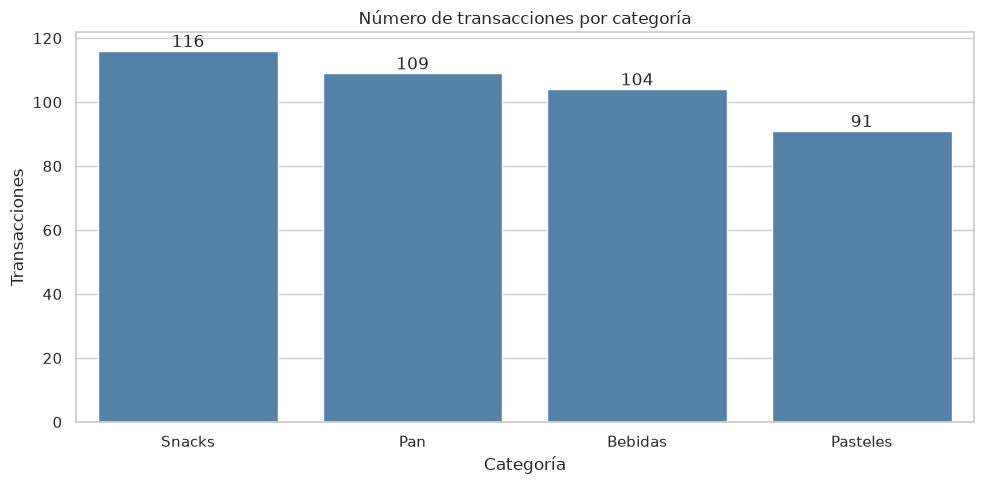

In [9]:
orden = frecuencia_categoria.index
ax = sns.countplot(data=df_limpio, x="category", order=orden, color="steelblue")
ax.set(title="Número de transacciones por categoría", xlabel="Categoría", ylabel="Transacciones")
for contenedor in ax.containers:
    ax.bar_label(contenedor)
plt.tight_layout()
plt.savefig(carpeta_figuras / "transacciones_por_categoria.jpg", dpi=150, bbox_inches="tight")
plt.show()

**Conclusión 1.3.** La tabla de frecuencias y el gráfico de barras muestran que `Snacks` tiene más
transacciones (116; 27,62 %) y `Pasteles` menos (91; 21,67 %). Este resumen ayuda a decidir qué
categorías necesitan mayor frecuencia de reabastecimiento, aunque debe complementarse con unidades
vendidas y valor monetario.

### 1.4 — Forma de la distribución y valores atípicos

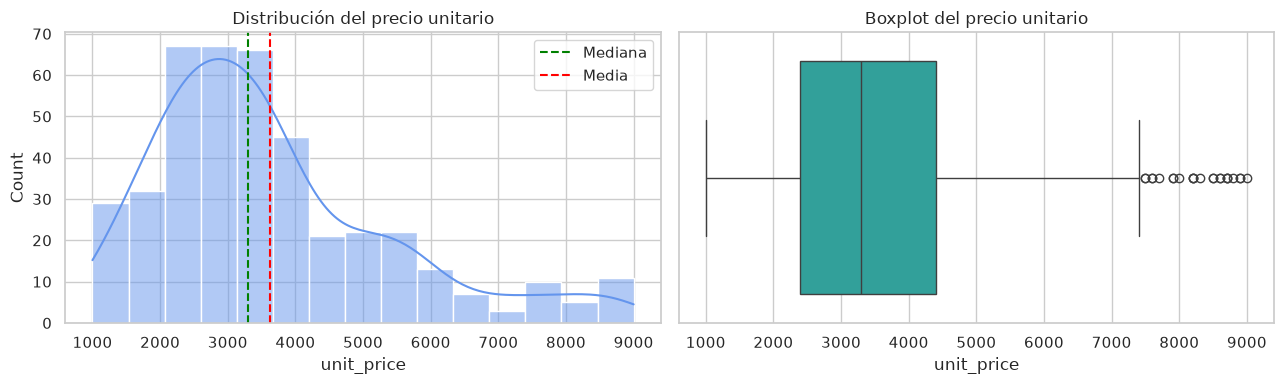

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_limpio["unit_price"], bins=15, kde=True, ax=axes[0], color="cornflowerblue")
axes[0].axvline(df_limpio["unit_price"].median(), color="green", linestyle="--", label="Mediana")
axes[0].axvline(df_limpio["unit_price"].mean(), color="red", linestyle="--", label="Media")
axes[0].set_title("Distribución del precio unitario")
axes[0].legend()
sns.boxplot(x=df_limpio["unit_price"], ax=axes[1], color="lightseagreen")
axes[1].set_title("Boxplot del precio unitario")
plt.tight_layout()
plt.savefig(carpeta_figuras / "distribucion_precio_unitario.jpg", dpi=150, bbox_inches="tight")
plt.show()

**Respuesta 1.4.** Se observa una distribución sesgada a la derecha: la mayoría de productos tiene
precios bajos o medios y algunos pasteles alcanzan precios más altos. Un valor alto puede ser
**atípico pero real** si coincide con el catálogo, la categoría y otras ventas similares. Se trata
como **error de captura** si rompe el rango comercial y el patrón sugiere un error sistemático; por
ejemplo, 540.000 COP cuando los productos comparables cuestan cerca de 5.400 COP.

### 1.5 — ¿Por qué la misma media puede exigir decisiones distintas?

In [11]:
# Ejemplo pequeño con la misma media, pero dispersión diferente
escenario_estable = pd.Series([3400, 3500, 3600, 3700, 3800])
escenario_variable = pd.Series([1000, 2000, 3600, 5200, 6200])

pd.DataFrame({
    "Media": [escenario_estable.mean(), escenario_variable.mean()],
    "Desviación estándar": [escenario_estable.std(), escenario_variable.std()],
    "Mínimo": [escenario_estable.min(), escenario_variable.min()],
    "Máximo": [escenario_estable.max(), escenario_variable.max()]
}, index=["Precios estables", "Precios variables"]).round(2)

,Media,Desviación estándar,Mínimo,Máximo
Precios estables,3600.0,158.11,3400,3800
Precios variables,3600.0,2158.70,1000,6200


**Respuesta 1.5.** Los dos escenarios tienen un precio medio de 3.600 COP, pero el segundo mezcla
precios muy bajos y muy altos. El primero permite una política de inventario uniforme; el segundo
exige segmentar por producto y controlar por separado los artículos costosos. La media no muestra
por sí sola la dispersión ni el riesgo.

---
## Parte 2 — Diagnóstico y transformación del archivo contaminado

Primero se diagnostica; todavía no se corrigen los datos.

In [12]:
diagnostico_basico = pd.DataFrame({
    "Nulos": df_contaminado.isna().sum(),
    "Tipo en pandas": df_contaminado.dtypes.astype(str)
})

diagnostico_basico["metodo_deteccion"] = ""

diagnostico_basico.loc[:, "metodo_deteccion"] = "df.isnull().sum()"
diagnostico_basico.loc["transaction_id", "metodo_deteccion"] = "df['transaction_id'].duplicated().sum()"
diagnostico_basico.loc["category", "metodo_deteccion"] = "df['category'].unique()"
diagnostico_basico.loc["date", "metodo_deteccion"] = "df['date'].sample(15)"
diagnostico_basico.loc["units_sold", "metodo_deteccion"] = "df['units_sold'].describe()"

diagnostico_basico

,Nulos,Tipo en pandas,metodo_deteccion
transaction_id,0,object,df['transaction_id'].duplicated().sum()
store_id,0,object,df.isnull().sum()
comuna,0,object,df.isnull().sum()
date,10,object,df['date'].sample(15)
category,0,object,df['category'].unique()
units_sold,21,float64,df['units_sold'].describe()
unit_price,12,float64,df.isnull().sum()
payment_method,0,object,df.isnull().sum()
customer_rating,64,float64,df.isnull().sum()
store_lat,0,float64,df.isnull().sum()


In [13]:
print("Duplicados exactos adicionales:", df_contaminado.duplicated().sum())
print("IDs de transacción repetidos:", df_contaminado["transaction_id"].duplicated().sum())
print("\nEtiquetas originales de category:")
print(sorted(df_contaminado["category"].unique()))

Duplicados exactos adicionales: 1
IDs de transacción repetidos: 10

Etiquetas originales de category:
[' Pan', ' Pasteles', 'BEBIDAS ', 'Bebida', 'Bebidas', 'PAN', 'PASTELES', 'Pan', 'Panes', 'Pastel', 'Pasteles', 'SNACKS', 'Snacks', 'Snaks', 'bebidas', 'pan', 'pan ', 'pasteles', 'snack']


In [14]:
# Reglas sencillas para detectar rangos imposibles
unidades_invalidas = df_contaminado["units_sold"].notna() & (df_contaminado["units_sold"] <= 0)
ratings_invalidos = (
    df_contaminado["customer_rating"].notna()
    & ~df_contaminado["customer_rating"].between(1, 5)
)
precios_sospechosos = df_contaminado["unit_price"] >= 100_000
coordenadas_invalidas = ~(
    df_contaminado["store_lat"].between(6.1, 6.4)
    & df_contaminado["store_lon"].between(-75.7, -75.4)
)

pd.Series({
    "Unidades <= 0": unidades_invalidas.sum(),
    "Ratings fuera de 1 a 5": ratings_invalidos.sum(),
    "Precios >= 100.000 COP": precios_sospechosos.sum(),
    "Coordenadas fuera del rango": coordenadas_invalidas.sum()
}, name="Cantidad")

Unidades <= 0                  8
Ratings fuera de 1 a 5         6
Precios >= 100.000 COP         5
Coordenadas fuera del rango    6
Name: Cantidad, dtype: int64

In [15]:
# Conteo de formatos visibles de fecha
def formato_fecha(valor):
    if pd.isna(valor):
        return "Nulo"
    valor = str(valor)
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", valor):
        return "YYYY-MM-DD"
    if re.fullmatch(r"\d{2}/\d{2}/\d{4}", valor):
        return "DD/MM/YYYY"
    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", valor):
        return "MM-DD-YYYY"
    if re.search(r"[A-Za-z]", valor):
        return "Mes en texto"
    return "Otro"

df_contaminado["date"].map(formato_fecha).value_counts()

date
YYYY-MM-DD      325
DD/MM/YYYY       39
MM-DD-YYYY       28
Mes en texto     28
Nulo             10
Name: count, dtype: int64

### 2.1 — Diagnóstico de calidad

| Problema detectado | Columnas | Detección con pandas | Riesgo para el negocio |
|---|---|---|---|
| Faltantes: 10 fechas, 21 unidades, 12 precios y 64 ratings | `date`, `units_sold`, `unit_price`, `customer_rating` | `isna().sum()` | Subestima ventas, ingresos o insatisfacción. |
| 1 duplicado exacto adicional y 10 IDs repetidos | `transaction_id` y demás columnas | `duplicated()` y `duplicated(subset=...)` | Infla rotación e ingresos. |
| 19 textos para 4 categorías reales | `category` | `unique()` / `value_counts()` | Fragmenta una categoría en grupos falsos. |
| Fechas ISO, con `/`, con `-`, texto y nulos | `date` | patrones de texto y `to_datetime(..., errors="coerce")` | Asigna ventas al día o mes equivocado. |
| 8 cantidades negativas y 6 ratings fuera de 1–5 | `units_sold`, `customer_rating` | `between()` y comparaciones | Distorsiona demanda y satisfacción. |
| 5 precios con dos ceros adicionales | `unit_price` | regla comercial y revisión por categoría | Infla el ingreso y la dispersión. |
| 6 coordenadas en cero o fuera de Medellín | `store_lat`, `store_lon` | `between()` para latitud y longitud | Ubica tiendas en zonas incorrectas. |

El diagnóstico cubre completitud, unicidad y consistencia antes de modificar el archivo.

### 2.2 — Conversión de fechas

In [16]:
# El archivo mezcla DD/MM/YYYY con MM-DD-YYYY; por eso se separan ambos casos.
fechas_texto = df_contaminado["date"].astype("string")
usa_slash = fechas_texto.str.fullmatch(r"\d{2}/\d{2}/\d{4}", na=False)

fechas_convertidas = pd.Series(pd.NaT, index=df_contaminado.index, dtype="datetime64[ns]")
fechas_convertidas.loc[usa_slash] = pd.to_datetime(
    fechas_texto.loc[usa_slash], format="%d/%m/%Y", errors="coerce"
)
fechas_convertidas.loc[~usa_slash] = pd.to_datetime(
    fechas_texto.loc[~usa_slash], format="mixed", dayfirst=False, errors="coerce"
)

print("Fechas no convertibles o faltantes:", fechas_convertidas.isna().sum())
print("Rango convertido:", fechas_convertidas.min().date(), "a", fechas_convertidas.max().date())

Fechas no convertibles o faltantes: 10
Rango convertido: 2025-01-01 a 2025-06-29


**Decisión 2.2.** `errors="coerce"` evita detener el proceso y convierte lo no interpretable en
`NaT`. Si el 8 % no se convierte, se deja como nulo explícito y esas filas se excluyen solamente de
análisis temporales; no se inventa una fecha porque hacerlo puede mover ventas a un mes equivocado.
La fila puede conservarse para análisis por tienda o categoría.

### 2.3 — Estandarización de la categoría

In [17]:
mapa_categoria = {
    "bebida": "Bebidas",
    "bebidas": "Bebidas",
    "pan": "Pan",
    "panes": "Pan",
    "pastel": "Pasteles",
    "pasteles": "Pasteles",
    "snack": "Snacks",
    "snacks": "Snacks",
    "snaks": "Snacks"
}

categoria_limpia = (
    df_contaminado["category"]
    .str.strip()
    .str.lower()
    .map(mapa_categoria)
)

pd.DataFrame({
    "Original": df_contaminado["category"],
    "Estandarizada": categoria_limpia
}).drop_duplicates().sort_values(["Estandarizada", "Original"])

,Original,Estandarizada
112,BEBIDAS,Bebidas
169,Bebida,Bebidas
7,Bebidas,Bebidas
54,bebidas,Bebidas
121,Pan,Pan
178,PAN,Pan
3,Pan,Pan
259,Panes,Pan
388,pan,Pan
29,pan,Pan


**Decisión 2.3.** Se eliminan espacios, se pasa a minúscula y se aplica un diccionario. Se consideran
iguales únicamente las variantes claras de número, mayúsculas o error ortográfico (`Snaks`).
No se usa similitud automática sin revisión, porque podría unir productos realmente distintos.

### 2.4 — Georreferenciación

In [18]:
# Rango operativo aproximado usado para Medellín y las tiendas del archivo
geo_valida = (
    df_contaminado["store_lat"].between(6.1, 6.4)
    & df_contaminado["store_lon"].between(-75.7, -75.4)
)

df_contaminado.loc[
    ~geo_valida,
    ["transaction_id", "store_id", "store_lat", "store_lon"]
]

,transaction_id,store_id,store_lat,store_lon
125,T00011,S05,0.00000,0.00000
146,T00393,S06,0.00000,0.00000
304,T00338,S04,0.00000,0.00000
374,T00076,S01,46.20987,-75.56624
399,T00362,S02,46.24496,-75.58880
413,T00112,S04,46.27285,-75.59422


**Decisión 2.4.** Se valida latitud entre 6,1 y 6,4 y longitud entre −75,7 y −75,4. Una inversión
solo se corregiría automáticamente si al intercambiar ambos valores la pareja entra al rango y
coincide con la ubicación usual de la misma tienda. Los ceros o valores como latitud 46 se marcan
inválidos y se reemplazan con la mediana de coordenadas válidas de su `store_id`. Un intercambio
automático sin esa prueba puede fabricar una ubicación plausible pero falsa.

### 2.5 — Imputación y valores imposibles

In [19]:
# units_sold es un conteo: debe ser entero y mayor que cero.
unidades_validas = (
    df_contaminado["units_sold"].isna()
    | (
        (df_contaminado["units_sold"] > 0)
        & (df_contaminado["units_sold"] % 1 == 0)
    )
)

print("Filas con unidades imposibles:", (~unidades_validas).sum())
df_contaminado.loc[~unidades_validas, ["transaction_id", "units_sold"]]

Filas con unidades imposibles: 8


,transaction_id,units_sold
2,T00419,-2.0
111,T00368,-3.0
120,T00088,-4.0
123,T00322,-6.0
125,T00011,-4.0
188,T00304,-2.0
190,T00139,-3.0
319,T00267,-5.0


**Decisión 2.5.** Una venta debe contener un número entero mayor que cero. Los negativos no se
convierten con valor absoluto porque no sabemos si el error está en el signo o también en la
magnitud. Se pasan a nulo y se imputan con la mediana de unidades de su categoría. Esta estrategia
mantiene la fila, pero reduce artificialmente la variabilidad y puede acercar demasiado la demanda
de cada categoría a su valor típico.

### 2.6 — Duplicados y llave de negocio

In [20]:
duplicados_id = df_contaminado[
    df_contaminado.duplicated(subset="transaction_id", keep=False)
].sort_values("transaction_id")

duplicados_id[[
    "transaction_id", "date", "category", "units_sold",
    "unit_price", "customer_rating"
]]

,transaction_id,date,category,units_sold,unit_price,customer_rating
25,T00059,2025-01-31,Snacks,5.0,2100.0,5.0
377,T00059,2025-01-31,Snacks,5.0,2100.0,5.0
382,T00074,NaN,Pan,3.0,2200.0,3.0
402,T00074,2025-01-25,Pan,3.0,2200.0,3.0
23,T00081,01/02/2025,Bebidas,4.0,5800.0,4.0
167,T00081,2025-02-01,Bebidas,4.0,5800.0,4.0
77,T00103,2025-03-18,Pan,2.0,1700.0,3.0
82,T00103,18/03/2025,Pan,2.0,1700.0,3.0
95,T00120,2025-06-15,Bebidas,5.0,4700.0,2.0
226,T00120,2025-06-15,Bebidas,5.0,4700.0,NaN


**Decisión 2.6.** 

Una posible **llave de negocio** para detectar duplicados reales es la combinación de **`store_id + date + category + unit_price`**, ya que estos atributos describen el evento de venta mejor que **`transaction_id`**. Este último es un identificador técnico generado por el sistema y puede cambiar si una transacción se registra nuevamente debido a un error, un reintento o un problema en el proceso de captura. En ese caso, dos registros con diferentes `transaction_id` podrían corresponder a la misma venta.

Un **duplicado exacto de fila** ocurre cuando todas las columnas tienen los mismos valores, lo que normalmente indica un problema de carga o almacenamiento de datos. En cambio, un **duplicado de evento de negocio** ocurre cuando la misma venta se registra más de una vez, aunque algunos campos (como `transaction_id`) sean diferentes. Por ello, para identificar duplicados reales es necesario comparar los atributos que describen el evento de negocio y no depender únicamente de un identificador técnico.

---
## 3. Limpieza reproducible

El siguiente bloque reúne las decisiones anteriores. El archivo limpio de referencia no se usa para
rellenar valores; solamente se contrasta al final.

In [21]:
df = df_contaminado.copy()

# 1. Categorías
df["category"] = df["category"].str.strip().str.lower().map(mapa_categoria)

# 2. Fechas
texto = df["date"].astype("string")
slash = texto.str.fullmatch(r"\d{2}/\d{2}/\d{4}", na=False)
df["date"] = pd.NaT
df.loc[slash, "date"] = pd.to_datetime(texto.loc[slash], format="%d/%m/%Y", errors="coerce")
df.loc[~slash, "date"] = pd.to_datetime(
    texto.loc[~slash], format="mixed", dayfirst=False, errors="coerce"
)
df["date"] = pd.to_datetime(df["date"])

# 3. Valores imposibles
df.loc[df["units_sold"] <= 0, "units_sold"] = np.nan
df.loc[~df["customer_rating"].between(1, 5), "customer_rating"] = np.nan

# Los cinco precios >= 100.000 tienen dos ceros adicionales.
# Solo se corrigen si dividir por 100 produce un valor dentro del rango comercial 1.000–9.000.
precio_corregido = df["unit_price"] / 100
error_dos_ceros = (df["unit_price"] >= 100_000) & precio_corregido.between(1_000, 9_000)
df.loc[error_dos_ceros, "unit_price"] = precio_corregido.loc[error_dos_ceros]

# 4. Imputación de variables necesarias para estimar demanda e ingreso
df["units_sold"] = df["units_sold"].fillna(
    df.groupby("category")["units_sold"].transform("median")
).round().astype("Int64")
df["unit_price"] = df["unit_price"].fillna(
    df.groupby("category")["unit_price"].transform("median")
)

# El rating faltante se conserva: no se fabrica satisfacción.
df["customer_rating"] = df["customer_rating"].astype("Int64")

# 5. Coordenadas: usar la ubicación típica de la misma tienda
geo_ok = (
    df["store_lat"].between(6.1, 6.4)
    & df["store_lon"].between(-75.7, -75.4)
)
medianas_geo = df.loc[geo_ok].groupby("store_id")[["store_lat", "store_lon"]].median()
for columna in ["store_lat", "store_lon"]:
    df.loc[~geo_ok, columna] = df.loc[~geo_ok, "store_id"].map(medianas_geo[columna])

# 6. Duplicados de negocio: conservar la versión más completa
df["_completitud"] = df.notna().sum(axis=1)
df = (
    df.sort_values("_completitud", ascending=False)
      .drop_duplicates(subset="transaction_id", keep="first")
      .drop(columns="_completitud")
      .sort_values("transaction_id")
      .reset_index(drop=True)
)

print("Dimensiones finales:", df.shape)
display(df.head())

Dimensiones finales: (420, 11)


,transaction_id,store_id,comuna,date,category,units_sold,unit_price,payment_method,customer_rating,store_lat,store_lon
0,T00001,S02,Laureles,2025-05-09,Bebidas,2,5100.0,App,5,6.24625,-75.58917
1,T00002,S02,Laureles,2025-06-03,Pasteles,4,8900.0,App,3,6.24605,-75.58977
2,T00003,S07,Aranjuez,2025-05-31,Snacks,1,3300.0,Tarjeta,4,6.27391,-75.55584
3,T00004,S04,Robledo,2025-06-07,Pan,3,3200.0,Efectivo,5,6.27054,-75.59354
4,T00005,S02,Laureles,2025-01-26,Bebidas,5,2100.0,Tarjeta,3,6.24270,-75.58825


**Nota de coherencia — 2.6 vs. limpieza aplicada.** La sección 2.6 argumenta que la llave de
negocio `store_id + date + category + unit_price` identifica mejor un evento de venta que
`transaction_id`. En el archivo crudo, sin embargo, `duplicated(subset=llave)` detecta 2 pares
(4 filas), mientras que `duplicated(subset="transaction_id")` detecta 10 pares (20 filas).
La llave declarada no marca los pares con `transaction_id` `T00074`, `T00081`, `T00103`,
`T00172`, `T00174`, `T00289`, `T00327` y `T00391`, porque la contaminación cambió al menos
uno de sus componentes entre copias: el formato o la ausencia de la fecha, la escritura de la
categoría o la ausencia del precio. Aplicar la llave declarada dejaría esos ocho duplicados sin
marcar. Por eso esta celda mantiene
`transaction_id` como llave práctica de deduplicación: es el único campo que la contaminación
no corrompió en ninguna de las dos copias de cada duplicado. El argumento de 2.6 sigue siendo
válido en general -`transaction_id` puede fallar si el sistema lo regenera-, pero en este
archivo concreto resultó ser el campo más confiable, precisamente porque los otros también
estaban contaminados.

In [22]:
# Verificación de reglas, sin comparar todavía valores celda a celda con el archivo limpio
verificacion = pd.Series({
    "IDs duplicados": df["transaction_id"].duplicated().sum(),
    "Categorías no reconocidas": df["category"].isna().sum(),
    "Unidades nulas o <= 0": (df["units_sold"].isna() | (df["units_sold"] <= 0)).sum(),
    "Precios nulos o <= 0": (df["unit_price"].isna() | (df["unit_price"] <= 0)).sum(),
    "Ratings fuera de 1 a 5": (
        df["customer_rating"].notna() & ~df["customer_rating"].between(1, 5)
    ).sum(),
    "Coordenadas inválidas": (~(
        df["store_lat"].between(6.1, 6.4)
        & df["store_lon"].between(-75.7, -75.4)
    )).sum()
}, name="Cantidad")
verificacion

IDs duplicados               0
Categorías no reconocidas    0
Unidades nulas o <= 0        0
Precios nulos o <= 0         0
Ratings fuera de 1 a 5       0
Coordenadas inválidas        0
Name: Cantidad, dtype: int64

In [23]:
# Exportación del resultado procesado: la guía asigna data/processed/ al resultado de la Tarea 3.
carpeta_procesados = raiz_proyecto / "data" / "processed"
carpeta_procesados.mkdir(parents=True, exist_ok=True)
ruta_salida = carpeta_procesados / "retail_ventas_PROCESADO.csv"
df.to_csv(ruta_salida, index=False, date_format="%Y-%m-%d")
print("Archivo guardado en:", ruta_salida)

Archivo guardado en: /home/andres/Documents/Universidad/ciencia_datos/taller1/data/processed/retail_ventas_PROCESADO.csv


In [24]:
# Validación final contra la referencia: se compara, no se usa para sobrescribir.
print("Filas procesadas / referencia:", len(df), "/", len(df_limpio))
print("Mismas 4 categorías:",
      set(df["category"].dropna()) == set(df_limpio["category"]))
print("Mismos identificadores:",
      set(df["transaction_id"]) == set(df_limpio["transaction_id"]))

Filas procesadas / referencia: 420 / 420
Mismas 4 categorías: True
Mismos identificadores: True


**Resultado de la limpieza.** Se recuperan 420 eventos únicos y las cuatro categorías esperadas.
Las fechas sin evidencia y los ratings faltantes permanecen nulos. Las imputaciones de unidades y
precios deben entenderse como estimaciones: permiten resumir demanda e ingreso, pero no recuperan
el valor original con certeza.

---
## Parte 3 — Interpretación y decisión para Retail

### Resumen por categoría

In [25]:
analisis = df.copy()
analisis["ingreso"] = analisis["units_sold"] * analisis["unit_price"]

resumen_categoria = analisis.groupby("category").agg(
    transacciones=("transaction_id", "count"),
    unidades_totales=("units_sold", "sum"),
    unidades_promedio=("units_sold", "mean"),
    precio_promedio=("unit_price", "mean"),
    rating_mediano=("customer_rating", "median"),
    ingreso_total=("ingreso", "sum")
).round(2).sort_values("unidades_promedio", ascending=False)

resumen_categoria

,transacciones,unidades_totales,unidades_promedio,precio_promedio,rating_mediano,ingreso_total
category,,,,,,
Pan,109,445,4.08,2640.37,4.0,1176400.0
Snacks,116,388,3.34,2506.90,4.0,996100.0
Bebidas,104,293,2.82,3931.73,4.0,1137900.0
Pasteles,91,243,2.67,5773.63,4.0,1404500.0


## Tarea 4 — Analítica descriptiva sobre los datos propios

Sobre `analisis` (los datos ya limpios del equipo, no el archivo de referencia): se describen
dos variables continuas y una discreta con medida de centro y dispersión justificada, dos
variables categóricas con tabla de frecuencia y una tabla de contingencia categórica × ordinal.
Las visualizaciones de esta tarea son las mismas de más abajo (por categoría y por tienda), ya
identificadas como suficientes.

In [26]:
variables_cuantitativas = ["units_sold", "unit_price", "ingreso"]
cuantitativas = analisis[variables_cuantitativas].agg(["mean", "median", "std"]).T
cuantitativas["iqr"] = (
    analisis[variables_cuantitativas].quantile(0.75)
    - analisis[variables_cuantitativas].quantile(0.25)
)
cuantitativas.round(2)

,mean,median,std,iqr
units_sold,3.26,3.0,1.55,2.0
unit_price,3602.14,3300.0,1726.77,2000.0
ingreso,11225.95,10000.0,6847.81,9525.0


**Justificación — cuantitativas.** `unit_price` (continua) mantiene la asimetría positiva ya
vista en 1.2: se prioriza la **mediana (3.300 COP)** sobre la media (3.602 COP). `units_sold`
(discreta) tiene media y mediana casi iguales (3,26 y 3,0) y una dispersión moderada (IQR de 2
unidades), por lo que la media es un resumen razonable para proyectar demanda. `ingreso`
(`units_sold * unit_price`, continua nueva) es la más sesgada de las tres: la media (11.226 COP)
queda por encima de la mediana (10.000 COP) y el máximo (35.600 COP) casi cuadruplica ese valor
típico. Ahí la mediana y el IQR (9.525 COP) describen mejor el ingreso típico por transacción que
la media y la desviación estándar, que un puñado de ventas grandes distorsiona.

In [27]:
frecuencia_pago = pd.DataFrame({
    "Frecuencia": analisis["payment_method"].value_counts(),
    "Proporción (%)": analisis["payment_method"].value_counts(normalize=True).mul(100).round(2)
})
frecuencia_pago

,Frecuencia,Proporción (%)
payment_method,,
App,142,33.81
Tarjeta,139,33.10
Efectivo,139,33.10


**Interpretación — forma de pago.** Los tres métodos están casi empatados: `App` 33,8 % (142),
`Tarjeta` 33,1 % (139) y `Efectivo` 33,1 % (139). No hay un canal dominante, así que cualquier
cambio operativo (por ejemplo, en S07) debe funcionar para los tres medios de pago por igual, no
solo para el más usado.

In [28]:
contingencia_rating = pd.crosstab(
    analisis["category"], analisis["customer_rating"], normalize="index"
).round(2)
contingencia_rating

customer_rating,1,2,3,4,5
category,,,,,
Bebidas,0.02,0.10,0.20,0.30,0.38
Pan,0.05,0.08,0.14,0.45,0.28
Pasteles,0.00,0.03,0.19,0.43,0.35
Snacks,0.02,0.06,0.14,0.51,0.27


**Interpretación — tabla de contingencia.** En `Pan`, `Pasteles` y `Snacks` la mayor proporción
de transacciones cae en rating 4 (entre 43 % y 51 %). `Bebidas` es la excepción: su pico está en
rating 5 (38 %), y el rating 4 es ahí el más bajo de las cuatro categorías (30 %). `Pan` es,
además, la categoría con mayor proporción de rating 1 (5 %). La forma de la satisfacción cambia
según qué se vende, así que un solo rating promedio por tienda (como el de 3.A) esconde estas
diferencias por categoría.

In [29]:
resumen_tienda = analisis.groupby(["store_id", "comuna"]).agg(
    transacciones=("transaction_id", "count"),
    rating_mediano=("customer_rating", "median"),
    rating_promedio=("customer_rating", "mean")
).round(2).sort_values("rating_promedio")

resumen_tienda

,,transacciones,rating_mediano,rating_promedio
store_id,comuna,,,
S07,Aranjuez,40,4.0,3.77
S05,Envigado,55,4.0,3.82
S02,Laureles,48,4.0,3.95
S06,Buenos Aires,54,4.0,3.96
S03,Belén,57,4.0,3.98
S08,Castilla,70,4.0,4.0
S01,El Poblado,51,4.0,4.03
S04,Robledo,45,4.0,4.05


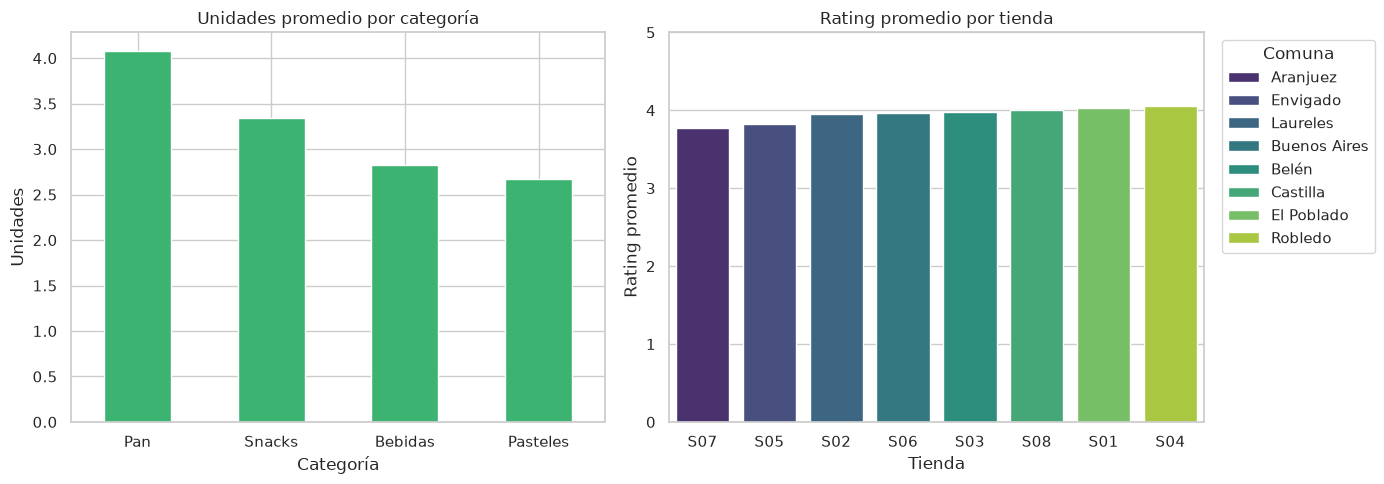

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_categoria["unidades_promedio"].plot(
    kind="bar", ax=axes[0], color="mediumseagreen"
)
axes[0].set(title="Unidades promedio por categoría", xlabel="Categoría", ylabel="Unidades")
axes[0].tick_params(axis="x", rotation=0)

orden_tiendas = resumen_tienda.reset_index()
sns.barplot(
    data=orden_tiendas,
    x="store_id",
    y="rating_promedio",
    hue="comuna",
    dodge=False,
    ax=axes[1],
    palette="viridis"
)
axes[1].set(title="Rating promedio por tienda", xlabel="Tienda", ylabel="Rating promedio")
axes[1].set_ylim(0, 5)
axes[1].legend(title="Comuna", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(carpeta_figuras / "resumen_categoria_tienda.jpg", dpi=150, bbox_inches="tight")
plt.show()

**Nota de coherencia — Prioridad 2.** Esta sección usa `df` (el resultado propio de la Tarea 3),
no `retail_ventas_LIMPIO.csv`. La diferencia es pequeña: con el archivo de referencia, `Pan`
tenía 4,06 unidades promedio por transacción y las tiendas peor calificadas eran S07 (3,72) y
S05 (3,73); con los datos propios son 4,08 unidades y 3,77 / 3,82 respectivamente. La
imputación por mediana de categoría y por tienda introduce ese margen, pero no cambia ninguna
conclusión de la sección 3.A: `Pan` sigue siendo el producto de mayor rotación y S07/S05 siguen
siendo las tiendas de menor calificación. Si las conclusiones hubieran cambiado, habría sido una
señal de que el archivo de referencia estaba corrigiendo algo que el proceso propio de limpieza
no capturó.

### 3.A — Decisión de inventario

**a)** `Pan` tiene la mayor rotación promedio (4,08 unidades por transacción) y un precio promedio
relativamente bajo (2.640 COP). Conviene asegurar su disponibilidad con reposiciones pequeñas y
frecuentes: quedarse corto pierde ventas recurrentes, mientras un exceso aumenta merma por ser un
producto perecedero. `Pasteles` genera el mayor ingreso observado, así que el presupuesto no debe
asignarse mirando únicamente unidades.

**b)** Las tiendas con menor calificación promedio son **S07–Aranjuez (3,77)** y
**S05–Envigado (3,82)**. La diferencia es mínima, por lo que ambas merecen diagnóstico. Con las
reseñas ya integradas (Tarea 1), la hipótesis deja de ser especulativa: en S07 la queja más
repetida es *"El local estaba desordenado"* (5 de 27 reseñas), lo que apunta a un problema
operativo de la tienda -orden, limpieza, atención- y no a falta de inventario. Antes de invertir
en reposición, S07 necesita también una revisión operativa, no solo más stock.

**c) Recomendación al gerente.** Priorizar un piloto de reposición frecuente de Pan en S07 y S05,
acompañado de una revisión operativa del servicio en horas pico. Proteger también el abastecimiento
de Pasteles por su mayor ingreso total. Medir durante cuatro semanas quiebres, merma y distribución
de ratings. No actuar arriesga pérdida de ventas y clientes; sobrerreaccionar puede elevar el
desperdicio.

---
## Decisión recomendada

1. **Pregunta de negocio:** ¿qué categoría y qué tienda presentan mayor riesgo de perder ventas o
   clientes por falta de inventario o servicio deficiente?
2. **Acción:** piloto de reposición frecuente de Pan y revisión operativa en S07 y S05, sin descuidar
   Pasteles por su aporte monetario.
3. **Falso positivo:** intervenir una tienda o aumentar inventario cuando no era necesario genera
   costo operativo, capital inmovilizado y merma.
4. **Falso negativo:** no intervenir donde sí existe el problema causa quiebres, ventas perdidas y
   deterioro de la experiencia del cliente.
5. **Limitación:** no hay costo, margen, inventario disponible ni hora de la venta, así que el
   precio no demuestra margen y no se puede separar un quiebre de stock de una caída de demanda.
   Las reseñas sí aportan la causa cualitativa, pero solo cubren 160 registros repartidos de forma
   desigual entre tiendas y no están ligadas a una venta específica: permiten hipótesis por tienda,
   no atribución por transacción.